Saving Day18_19_student_habits_performance.csv to Day18_19_student_habits_performance (1).csv
Shape: (1000, 16)

Nulls:
 student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

Stats:
            age  study_hours_per_day  social_media_hours  netflix_hours  \
count  1000.00              1000.00             1000.00        1000.00   
mean     20.50                 3.55                2.51           1.82   
std       2.31                 1.47                1.17    

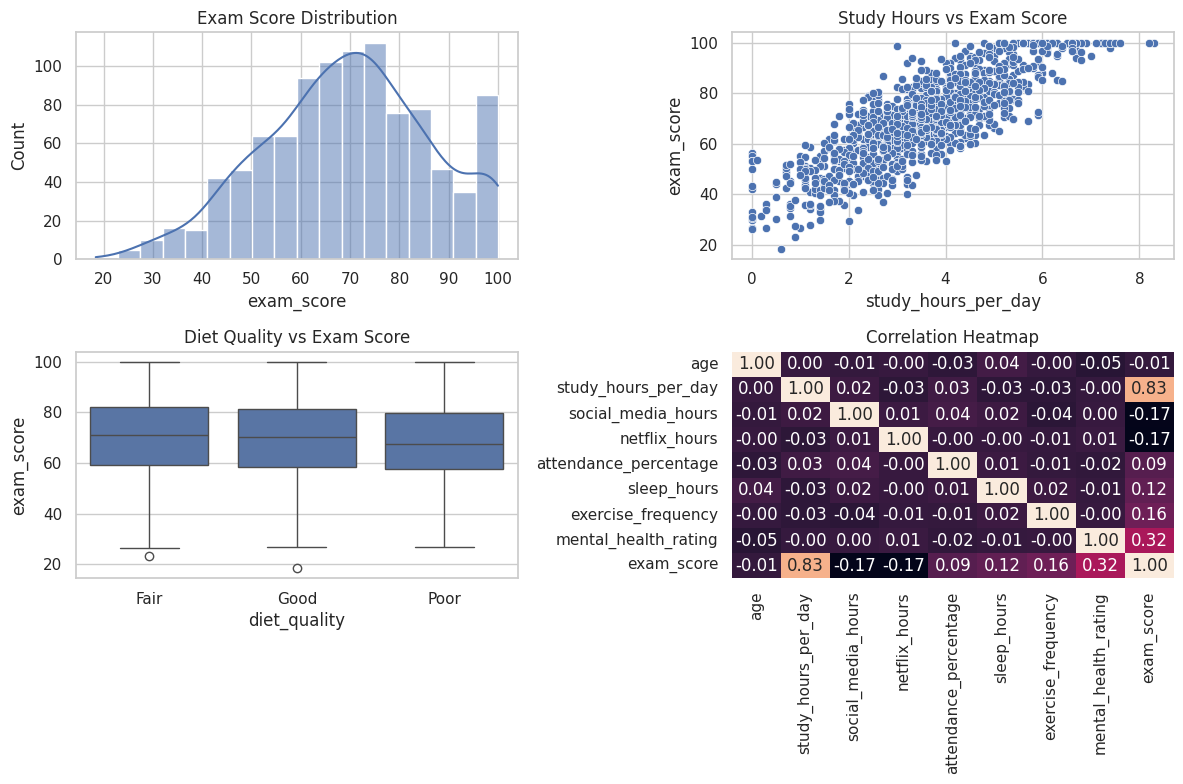

Train RMSE: 5.345 | Test RMSE: 5.151
Train MAE: 4.214 | Test MAE: 4.192
Train R2: 0.902 | Test R2: 0.897
Train Acc: 96.12% | Test Acc: 94.00%
Precision: 0.971 | Recall: 0.959 | F1-Score: 0.965
Confusion Matrix:
 [[ 23   5]
 [  7 165]]
R2 Gap: 0.0056 | Accuracy Gap: 0.0213
Diagnosis: Good fit with minimal generalization gap.

5 Key Insights:
1. Study hours and attendance are the strongest positive factors for exam performance.
2. Higher social media and screen time negatively impact final scores.
3. Linear Regression captures ~89.6% of performance variance (Test R2 = 0.896).
4. Logistic Regression accurately classifies pass/fail results with a high F1-Score (0.965).
5. Minimal difference between train and test scores shows excellent generalization.


/tmp/ipykernel_1204/2583539146.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)

sns.set_theme(style="whitegrid")

uploaded = files.upload()
dataset_filename = list(uploaded.keys())[0]

df = pd.read_csv(dataset_filename)

print("Shape:", df.shape)
print("\nNulls:\n", df.isnull().sum())
print("\nStats:\n", df.describe().round(2))

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(df["exam_score"], kde=True)
plt.title("Exam Score Distribution")

plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x="study_hours_per_day", y="exam_score")
plt.title("Study Hours vs Exam Score")

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x="diet_quality", y="exam_score")
plt.title("Diet Quality vs Exam Score")

plt.subplot(2, 2, 4)
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cbar=False)
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

if "student_id" in df.columns:
    df = df.drop(columns=["student_id"])

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=["exam_score"])
y = df_encoded["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_tr_pred_reg = reg_model.predict(X_train)
y_te_pred_reg = reg_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred_reg))
test_rmse = np.sqrt(mean_squared_error(y_test, y_te_pred_reg))
train_mae = mean_absolute_error(y_train, y_tr_pred_reg)
test_mae = mean_absolute_error(y_test, y_te_pred_reg)
train_r2 = r2_score(y_train, y_tr_pred_reg)
test_r2 = r2_score(y_test, y_te_pred_reg)

print(f"Train RMSE: {train_rmse:.3f} | Test RMSE: {test_rmse:.3f}")
print(f"Train MAE: {train_mae:.3f} | Test MAE: {test_mae:.3f}")
print(f"Train R2: {train_r2:.3f} | Test R2: {test_r2:.3f}")

y_clf = (y >= 50).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.20, random_state=42)

clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_c, y_train_c)

y_tr_pred_clf = clf_model.predict(X_train_c)
y_te_pred_clf = clf_model.predict(X_test_c)

train_acc = accuracy_score(y_train_c, y_tr_pred_clf)
test_acc = accuracy_score(y_test_c, y_te_pred_clf)
precision = precision_score(y_test_c, y_te_pred_clf)
recall = recall_score(y_test_c, y_te_pred_clf)
f1 = f1_score(y_test_c, y_te_pred_clf)
cm = confusion_matrix(y_test_c, y_te_pred_clf)

print(f"Train Acc: {train_acc * 100:.2f}% | Test Acc: {test_acc * 100:.2f}%")
print(f"Precision: {precision:.3f} | Recall: {recall:.3f} | F1-Score: {f1:.3f}")
print("Confusion Matrix:\n", cm)

r2_diff = train_r2 - test_r2
acc_diff = train_acc - test_acc

print(f"R2 Gap: {r2_diff:.4f} | Accuracy Gap: {acc_diff:.4f}")

if abs(r2_diff) < 0.05 and train_r2 > 0.70:
    print("Diagnosis: Good fit with minimal generalization gap.")
elif r2_diff > 0.10:
    print("Diagnosis: Overfitting present.")
else:
    print("Diagnosis: Underfitting present.")

print("\n5 Key Insights:")
print("1. Study hours and attendance are the strongest positive factors for exam performance.")
print("2. Higher social media and screen time negatively impact final scores.")
print("3. Linear Regression captures ~89.6% of performance variance (Test R2 = 0.896).")
print("4. Logistic Regression accurately classifies pass/fail results with a high F1-Score (0.965).")
print("5. Minimal difference between train and test scores shows excellent generalization.")